In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [103]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Fraud_Data.csv')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           590540 non-null  int64  
 1   is_fraud                 590540 non-null  int64  
 2   transaction_time         590540 non-null  int64  
 3   transaction_amount       590540 non-null  float64
 4   card_network             588963 non-null  object 
 5   card_type                588969 non-null  object 
 6   purchaser_email_domain   496084 non-null  object 
 7   device_type              140810 non-null  object 
 8   is_identity_seen_before  129340 non-null  object 
 9   user_os                  144233 non-null  object 
 10  user_browser             144233 non-null  object 
 11  environment              144233 non-null  object 
 12  environment_freq         144233 non-null  float64
 13  environment_risk         144233 non-null  float64
 14  devi

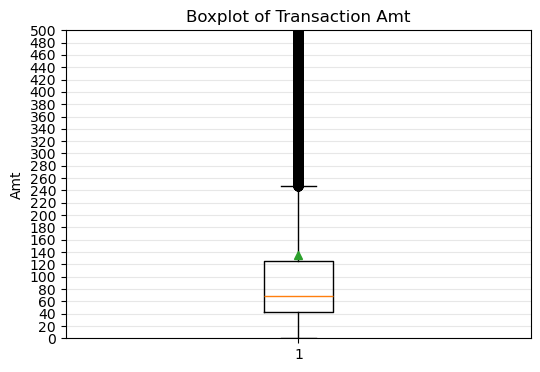

In [105]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    df['transaction_amount'],
    vert=True,
    showmeans=True
)

plt.title('Boxplot of Transaction Amt')
plt.ylabel('Amt')
plt.grid(axis='y', alpha=0.3)
# Adding limits
plt.ylim(0,500)
# more nums 
plt.yticks(range(0, 501, 20))
plt.show()

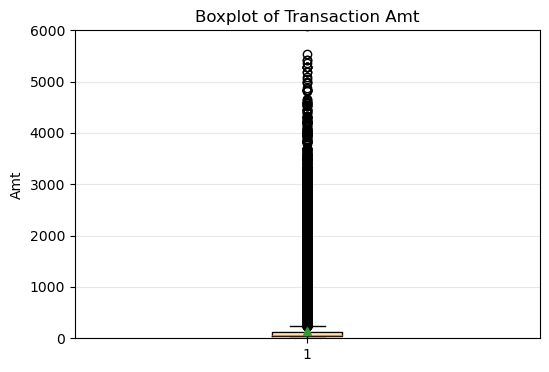

In [106]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    df['transaction_amount'],
    vert=True,
    showmeans=True
)

plt.title('Boxplot of Transaction Amt')
plt.ylabel('Amt')
plt.grid(axis='y', alpha=0.3)
# Adding limits
plt.ylim(0,6000)
# more nums 
# plt.yticks(range(0, 501, 20))
plt.show()

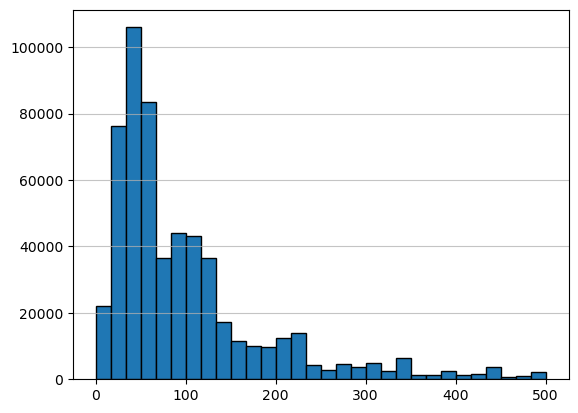

In [107]:
plt.hist(df['transaction_amount'], bins=30, edgecolor='black', range=(0,501))
plt.grid( axis='y', alpha=0.75)

In [108]:
df['card_network'].value_counts()

card_network
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

Text(0, 0.5, 'usage')

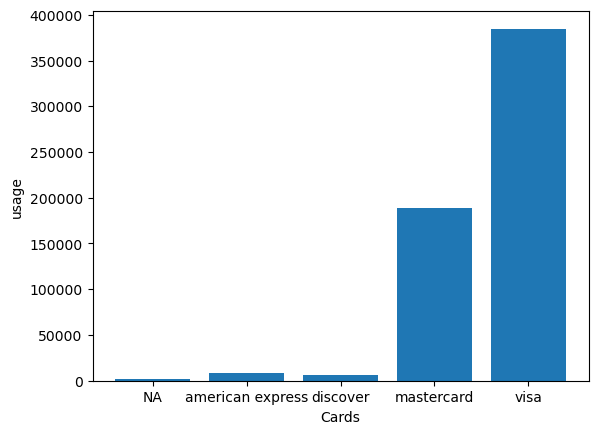

In [109]:
df['card_network'] = df['card_network'].fillna("NA")
card_net_counts = df['card_network'].value_counts().sort_index()
plt.bar(card_net_counts.index, card_net_counts.values)
plt.xlabel("Cards")
plt.ylabel("usage")

Text(0, 0.5, 'usage')

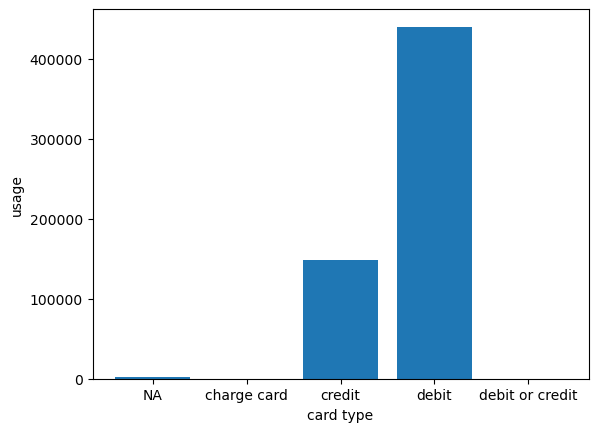

In [110]:
df['card_type'] = df['card_type'].fillna("NA")
card_type = df['card_type'].value_counts().sort_index()
plt.bar(card_type.index, card_type.values)
plt.xlabel('card type')
plt.ylabel('usage')

In [111]:
df['purchaser_email_domain'] = df['purchaser_email_domain'].fillna('NA')
df['purchaser_email_domain'].value_counts()

purchaser_email_domain
gmail.com           228355
yahoo.com           100934
NA                   94456
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com           280
embarqmail.com         260
web.d

In [112]:
df['transaction_time'].head

<bound method NDFrame.head of 0            86400
1            86401
2            86469
3            86499
4            86506
            ...   
590535    15811047
590536    15811049
590537    15811079
590538    15811088
590539    15811131
Name: transaction_time, Length: 590540, dtype: int64>

In [113]:
df.sort_values(by="transaction_time", inplace=True)

In [114]:
df['time(min)'] = df['transaction_time'] / 60

In [115]:
df['time(min)'] = df['time(min)'] - 1440
df['time(min)'] = df['time(min)'].round(3)
df[['time(min)', 'transaction_time']].head(10)

,time(min),transaction_time
0,0.000,86400
1,0.017,86401
2,1.150,86469
3,1.650,86499
4,1.767,86506
5,1.833,86510
6,2.033,86522
7,2.150,86529
8,2.250,86535
9,2.267,86536


In [116]:
df['time(hr)'] = (df['time(min)'] / 60).round(2)
df['time(days)'] = df['transaction_time'] // 86400
df[['time(min)', 'time(days)','time(hr)',  'transaction_time']].head(10)

,time(min),time(days),time(hr),transaction_time
0,0.000,1,0.00,86400
1,0.017,1,0.00,86401
2,1.150,1,0.02,86469
3,1.650,1,0.03,86499
4,1.767,1,0.03,86506
5,1.833,1,0.03,86510
6,2.033,1,0.03,86522
7,2.150,1,0.04,86529
8,2.250,1,0.04,86535
9,2.267,1,0.04,86536


In [117]:
print(df['time(days)'].max(), df['time(hr)'].duplicated().sum())

182 319020


In [118]:
df['time(days)'].tail()

590535    182
590536    182
590537    182
590538    182
590539    182
Name: time(days), dtype: int64